In [1]:
import cv2                  
import torch                
import torchvision          
import albumentations       
import matplotlib.pyplot as plt  
import sklearn              
import numpy as np         
import pandas as pd         
import seaborn as sns       
from tqdm import tqdm       
import yaml   
import os              


# Loading the Data

In [2]:
DATA_PATH = r"E:\Cardiff Uni\Semester 2\CMT307 Applied Machine Learning\Assessment Deep learning\archive"

# Load the CSV files
train_df = pd.read_csv(os.path.join(DATA_PATH, "Train.csv"))
test_df = pd.read_csv(os.path.join(DATA_PATH, "Test.csv"))
meta_df = pd.read_csv(os.path.join(DATA_PATH, "Meta.csv"))

print("=== Train CSV ===")
print(f"Shape: {train_df.shape}")
print(train_df.head())
print(f"\nColumns: {train_df.columns.tolist()}")

print("\n=== Test CSV ===")
print(f"Shape: {test_df.shape}")
print(test_df.head())

print("\n=== Meta CSV ===")
print(f"Shape: {meta_df.shape}")
print(meta_df.head())

=== Train CSV ===
Shape: (39209, 8)
   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId  \
0     27      26       5       5      22      20       20   
1     28      27       5       6      23      22       20   
2     29      26       6       5      24      21       20   
3     28      27       5       6      23      22       20   
4     28      26       5       5      23      21       20   

                             Path  
0  Train/20/00020_00000_00000.png  
1  Train/20/00020_00000_00001.png  
2  Train/20/00020_00000_00002.png  
3  Train/20/00020_00000_00003.png  
4  Train/20/00020_00000_00004.png  

Columns: ['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path']

=== Test CSV ===
Shape: (12630, 8)
   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId            Path
0     53      54       6       5      48      49       16  Test/00000.png
1     42      45       5       5      36      40        1  Test/00001.png
2     48      52       6       6  

# Class distribution

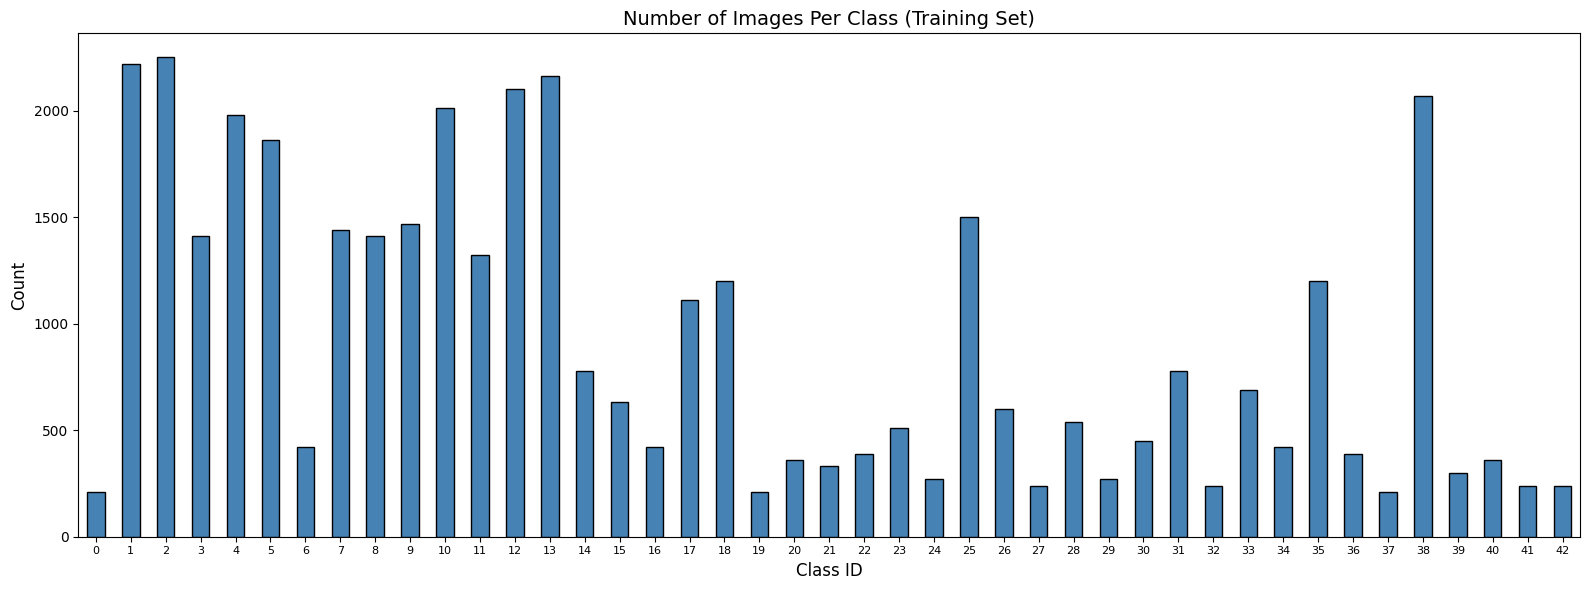

Most common class: 2 with 2250 images
Least common class: 0 with 210 images
Imbalance ratio: 10.7x


In [3]:
# Class distribution
plt.figure(figsize=(16, 6))
train_df['ClassId'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Number of Images Per Class (Training Set)', fontsize=14)
plt.xlabel('Class ID', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# Print the imbalance
print(f"Most common class: {train_df['ClassId'].value_counts().idxmax()} with {train_df['ClassId'].value_counts().max()} images")
print(f"Least common class: {train_df['ClassId'].value_counts().idxmin()} with {train_df['ClassId'].value_counts().min()} images")
print(f"Imbalance ratio: {train_df['ClassId'].value_counts().max() / train_df['ClassId'].value_counts().min():.1f}x")

# Image size distribution

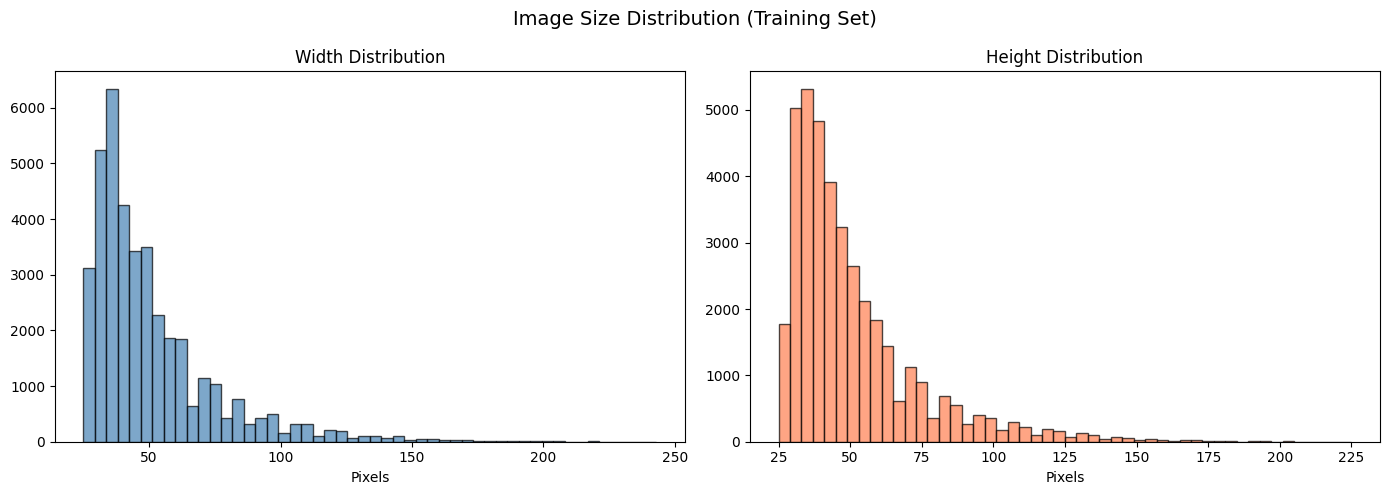

Width  — Min: 25, Max: 243, Mean: 50.8
Height — Min: 25, Max: 225, Mean: 50.3


In [4]:
# Image size analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_df['Width'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Width Distribution')
axes[0].set_xlabel('Pixels')

axes[1].hist(train_df['Height'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Height Distribution')
axes[1].set_xlabel('Pixels')

plt.suptitle('Image Size Distribution (Training Set)', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Width  — Min: {train_df['Width'].min()}, Max: {train_df['Width'].max()}, Mean: {train_df['Width'].mean():.1f}")
print(f"Height — Min: {train_df['Height'].min()}, Max: {train_df['Height'].max()}, Mean: {train_df['Height'].mean():.1f}")

#  Sample images from each class

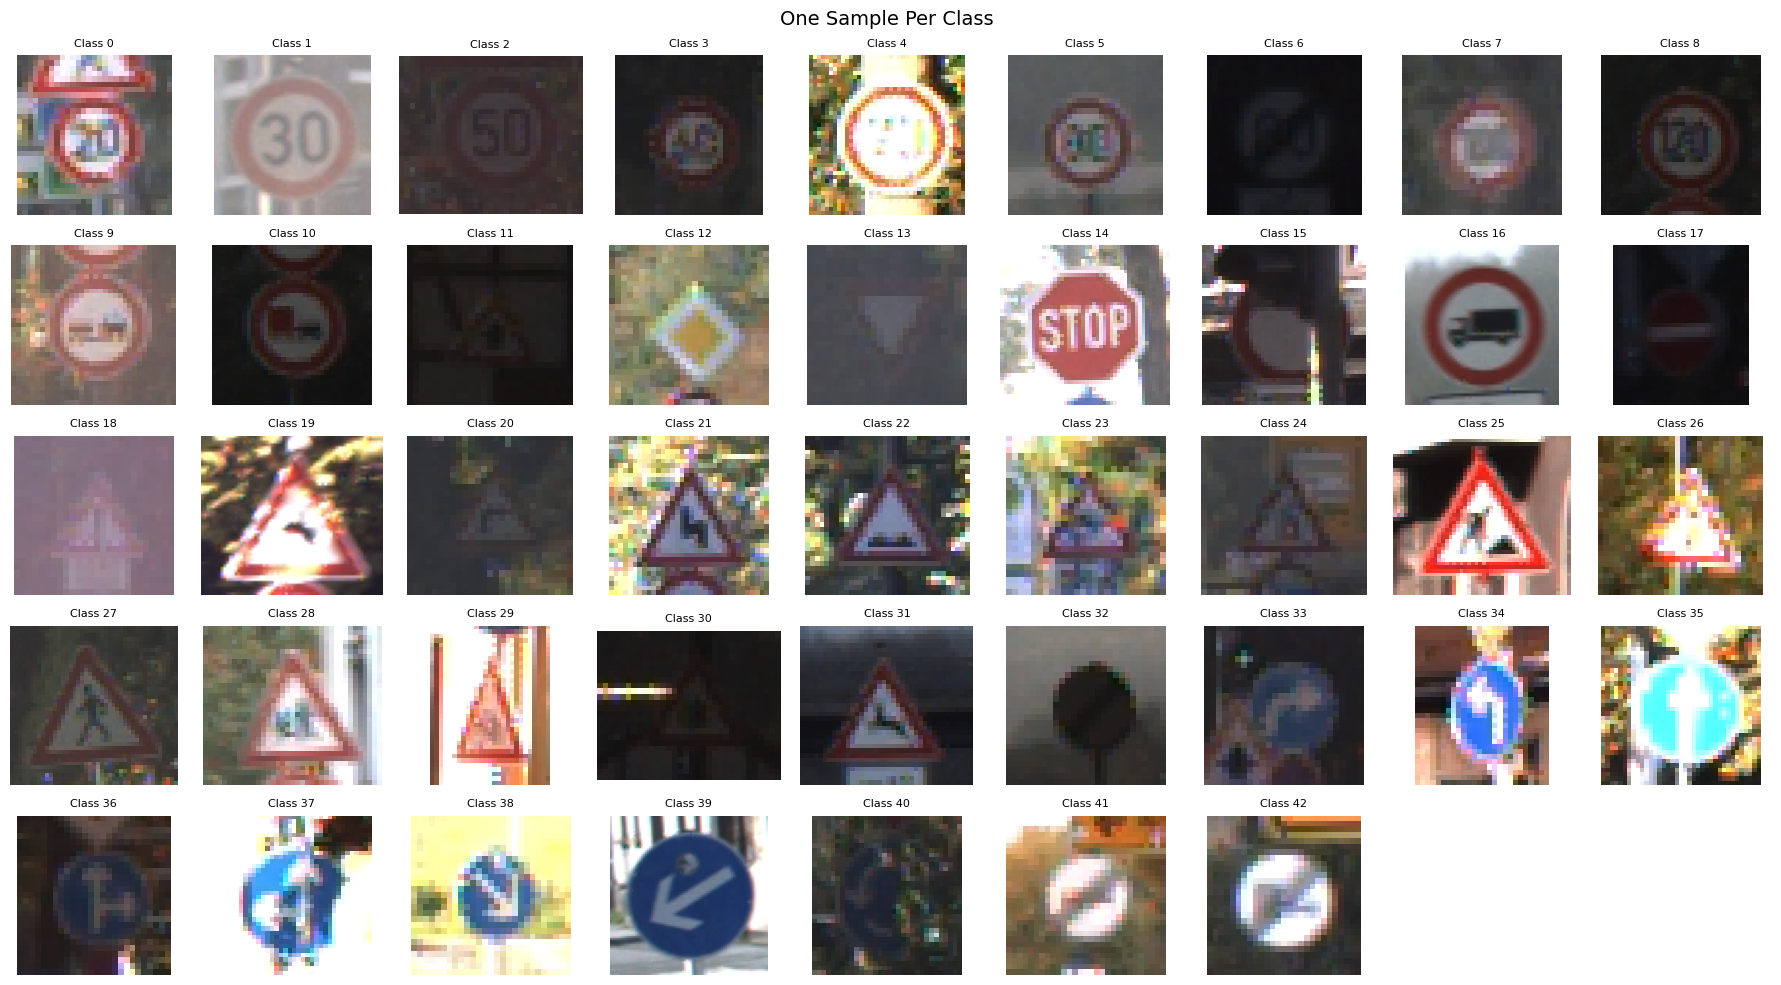

In [5]:
# Show one sample image from each class
fig, axes = plt.subplots(5, 9, figsize=(18, 10))
axes = axes.flatten()

for idx in range(43):
    sample = train_df[train_df['ClassId'] == idx].iloc[0]
    img_path = os.path.join(DATA_PATH, sample['Path'])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[idx].imshow(img)
    axes[idx].set_title(f'Class {idx}', fontsize=8)
    axes[idx].axis('off')

# Turn off remaining subplots
for idx in range(43, 45):
    axes[idx].axis('off')

plt.suptitle('One Sample Per Class', fontsize=14)
plt.tight_layout()
plt.show()

# ROI analysis (important for detection)

In [6]:
# ROI (bounding box) analysis
train_df['roi_width'] = train_df['Roi.X2'] - train_df['Roi.X1']
train_df['roi_height'] = train_df['Roi.Y2'] - train_df['Roi.Y1']
train_df['roi_ratio'] = train_df['roi_width'] / train_df['roi_height']

print(f"ROI Width  — Min: {train_df['roi_width'].min()}, Max: {train_df['roi_width'].max()}, Mean: {train_df['roi_width'].mean():.1f}")
print(f"ROI Height — Min: {train_df['roi_height'].min()}, Max: {train_df['roi_height'].max()}, Mean: {train_df['roi_height'].mean():.1f}")
print(f"Aspect Ratio — Mean: {train_df['roi_ratio'].mean():.2f}, Std: {train_df['roi_ratio'].std():.2f}")

ROI Width  — Min: 15, Max: 203, Mean: 39.2
ROI Height — Min: 15, Max: 185, Mean: 38.8
Aspect Ratio — Mean: 1.01, Std: 0.08


# Multiple samples from a single class to see variation

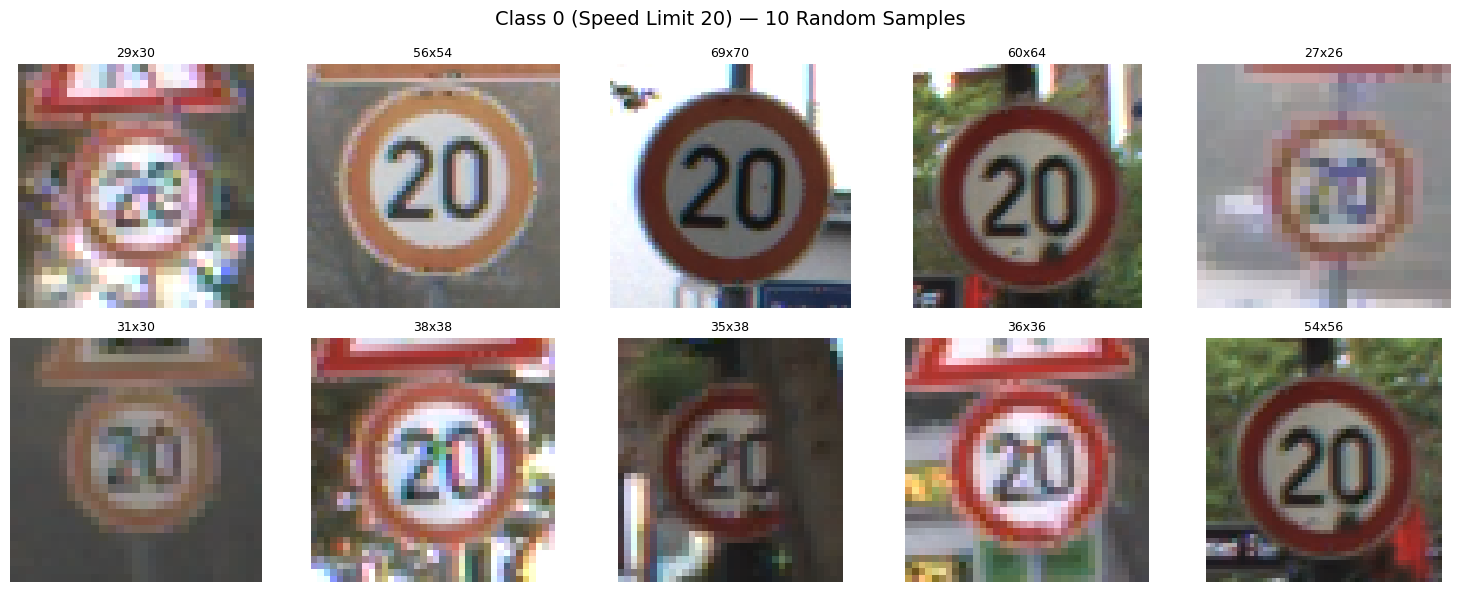

In [7]:
# Show variation within a single class (pick a small class)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

samples = train_df[train_df['ClassId'] == 0].sample(10, random_state=42)
for idx, (_, row) in enumerate(samples.iterrows()):
    img_path = os.path.join(DATA_PATH, row['Path'])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[idx].imshow(img)
    axes[idx].set_title(f"{row['Width']}x{row['Height']}", fontsize=9)
    axes[idx].axis('off')

plt.suptitle('Class 0 (Speed Limit 20) — 10 Random Samples', fontsize=14)
plt.tight_layout()
plt.show()

# Show the effect of ROI cropping

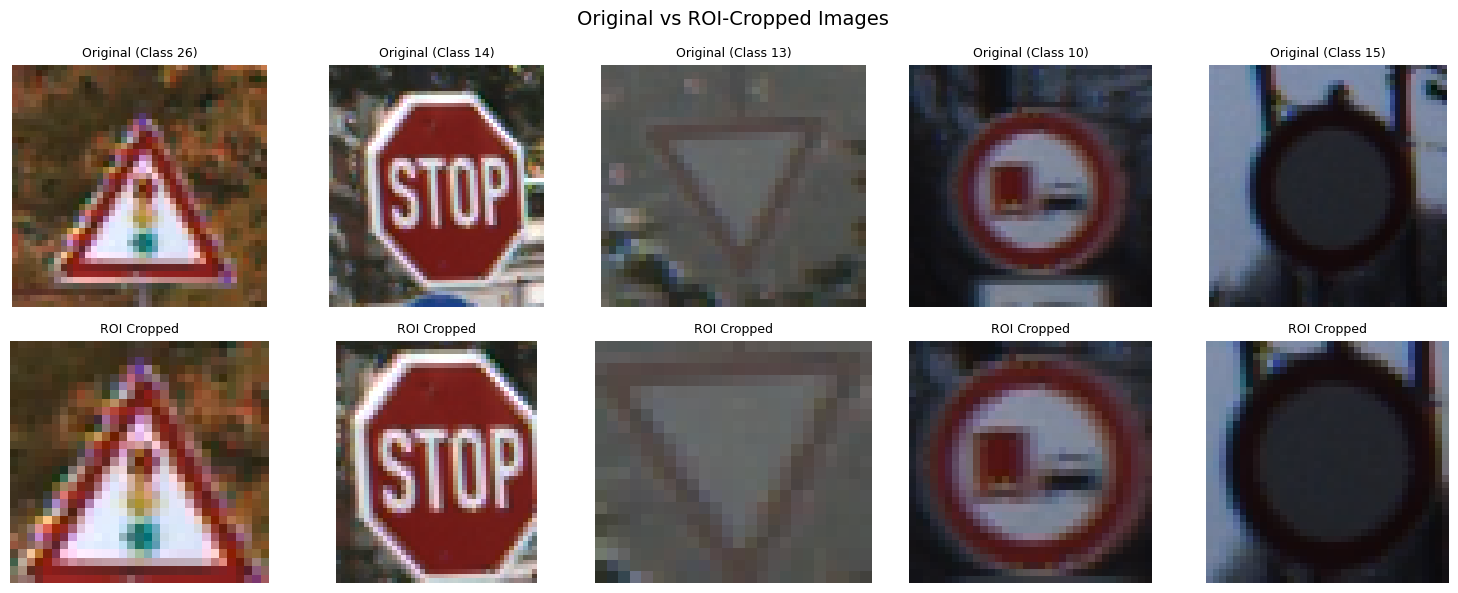

In [8]:
# Show original vs ROI-cropped
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

samples = train_df.sample(5, random_state=42)
for idx, (_, row) in enumerate(samples.iterrows()):
    img_path = os.path.join(DATA_PATH, row['Path'])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Original
    axes[0, idx].imshow(img)
    axes[0, idx].set_title(f'Original (Class {row["ClassId"]})', fontsize=9)
    axes[0, idx].axis('off')
    
    # ROI cropped
    roi = img[row['Roi.Y1']:row['Roi.Y2'], row['Roi.X1']:row['Roi.X2']]
    axes[1, idx].imshow(roi)
    axes[1, idx].set_title(f'ROI Cropped', fontsize=9)
    axes[1, idx].axis('off')

plt.suptitle('Original vs ROI-Cropped Images', fontsize=14)
plt.tight_layout()
plt.show()

# Create a validation split from training data

In [3]:
from sklearn.model_selection import train_test_split

# Stratified split to maintain class proportions
train_split, val_split = train_test_split(
    train_df, 
    test_size=0.2, 
    random_state=42, 
    stratify=train_df['ClassId']
)

print(f"Training samples: {len(train_split)}")
print(f"Validation samples: {len(val_split)}")
print(f"Test samples: {len(test_df)}")

# Verify stratification worked
print(f"\nClass 0 — Train: {len(train_split[train_split['ClassId']==0])}, Val: {len(val_split[val_split['ClassId']==0])}")
print(f"Class 2 — Train: {len(train_split[train_split['ClassId']==2])}, Val: {len(val_split[val_split['ClassId']==2])}")

Training samples: 31367
Validation samples: 7842
Test samples: 12630

Class 0 — Train: 168, Val: 42
Class 2 — Train: 1800, Val: 450


# PyTorch Dataset class

In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class GTSRBDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_path = os.path.join(self.root_dir, row['Path'])
        
        # Read image with OpenCV
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Apply CLAHE for contrast enhancement
        lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        lab[:, :, 0] = clahe.apply(lab[:, :, 0])
        image = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        
        # Apply transforms
        if self.transform:
            image = self.transform(image)
        
        label = torch.tensor(row['ClassId'], dtype=torch.long)
        return image, label

# Define transforms

In [5]:
IMG_SIZE = 48

# Training transforms (with augmentation)
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation/Test transforms (NO augmentation)
val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create DataLoaders

In [6]:
# Create datasets
train_dataset = GTSRBDataset(train_split, DATA_PATH, transform=train_transform)
val_dataset = GTSRBDataset(val_split, DATA_PATH, transform=val_transform)
test_dataset = GTSRBDataset(test_df, DATA_PATH, transform=val_transform)

# Create dataloaders
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

# Quick sanity check — grab one batch
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Label range: {labels.min()} to {labels.max()}")
print(f"Image value range: {images.min():.3f} to {images.max():.3f}")

Batch shape: torch.Size([64, 3, 48, 48])
Labels shape: torch.Size([64])
Label range: 0 to 40
Image value range: -2.118 to 2.640


# Visualize augmented samples

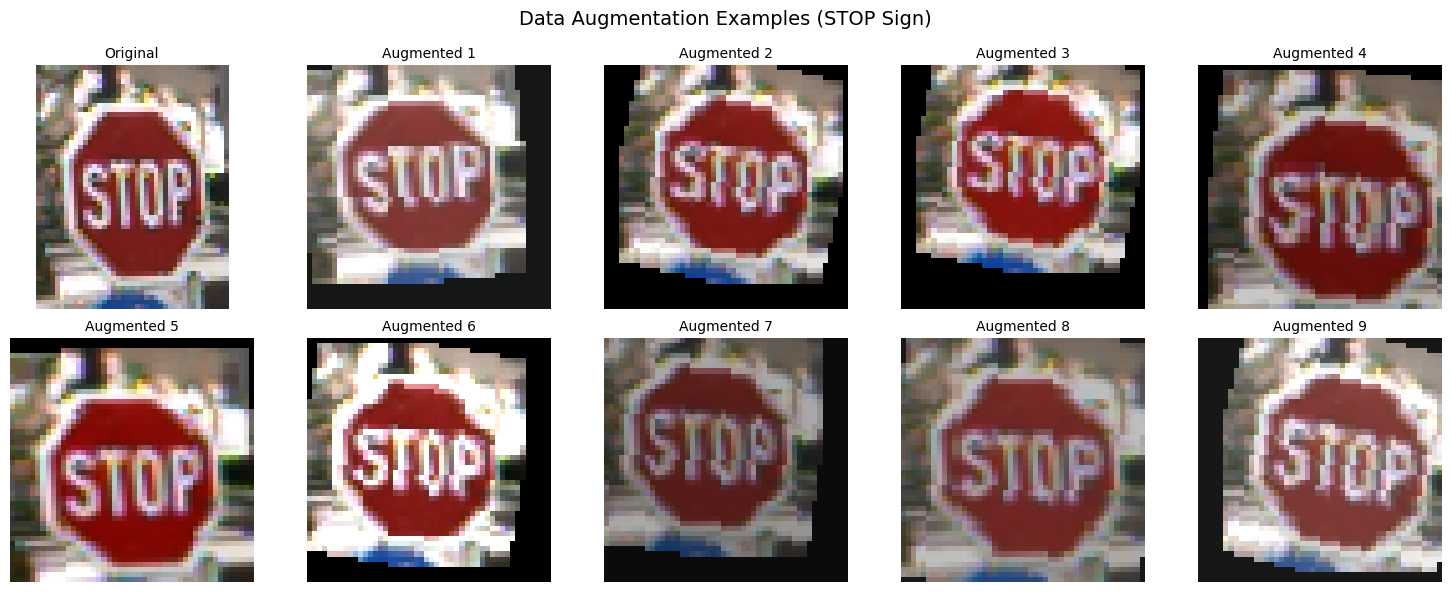

In [13]:
# Show augmented vs original
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

sample_row = train_split[train_split['ClassId'] == 14].iloc[0]  # STOP sign
img_path = os.path.join(DATA_PATH, sample_row['Path'])
original = cv2.imread(img_path)
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

axes[0, 0].imshow(original)
axes[0, 0].set_title('Original', fontsize=10)
axes[0, 0].axis('off')

# Show 9 augmented versions
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

for i in range(9):
    row_idx = (i + 1) // 5
    col_idx = (i + 1) % 5
    
    augmented = train_transform(original)
    augmented = inv_normalize(augmented)
    augmented = augmented.permute(1, 2, 0).numpy()
    augmented = np.clip(augmented, 0, 1)
    
    axes[row_idx, col_idx].imshow(augmented)
    axes[row_idx, col_idx].set_title(f'Augmented {i+1}', fontsize=10)
    axes[row_idx, col_idx].axis('off')

plt.suptitle('Data Augmentation Examples (STOP Sign)', fontsize=14)
plt.tight_layout()
plt.show()

# Class weights and device setup

In [7]:
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Compute class weights to handle imbalance
class_counts = train_split['ClassId'].value_counts().sort_index().values
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_weights)  # normalize
class_weights = torch.FloatTensor(class_weights).to(device)

print(f"\nClass weights (first 10): {class_weights[:10]}")
print(f"Min weight: {class_weights.min():.3f} (most common class)")
print(f"Max weight: {class_weights.max():.3f} (least common class)")

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU

Class weights (first 10): tensor([2.3673, 0.2239, 0.2209, 0.3526, 0.2511, 0.2673, 1.1836, 0.3452, 0.3526,
        0.3382], device='cuda:0')
Min weight: 0.221 (most common class)
Max weight: 2.367 (least common class)


# Training and evaluation functions (reusable for every model)

In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(loader, desc='Training', leave=False):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Evaluating', leave=False):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc, np.array(all_preds), np.array(all_labels)


def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, num_epochs=25, model_name='model'):
    """Full training loop with early stopping and best model saving."""
    
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    best_val_acc = 0.0
    patience = 5
    patience_counter = 0
    
    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
        
        if scheduler:
            scheduler.step(val_loss)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch [{epoch+1}/{num_epochs}] | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'best_{model_name}.pth')
            patience_counter = 0
            print(f"  → New best model saved! (Val Acc: {val_acc:.2f}%)")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  → Early stopping triggered after {epoch+1} epochs")
                break
    
    # Load best model
    model.load_state_dict(torch.load(f'best_{model_name}.pth'))
    print(f"\nBest validation accuracy: {best_val_acc:.2f}%")
    return model, history


def plot_training_history(history, model_name='Model'):
    """Plot training curves."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(history['train_loss'], label='Train', linewidth=2)
    axes[0].plot(history['val_loss'], label='Validation', linewidth=2)
    axes[0].set_title(f'{model_name} — Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(history['train_acc'], label='Train', linewidth=2)
    axes[1].plot(history['val_acc'], label='Validation', linewidth=2)
    axes[1].set_title(f'{model_name} — Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{model_name}_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

# Baseline CNN architecture

In [9]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=43):
        super(BaselineCNN, self).__init__()
        
        # Block 1
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25)
        )
        
        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25)
        )
        
        # Block 3
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25)
        )
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 6 * 6, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x

# Instantiate and check
model_baseline = BaselineCNN(num_classes=43).to(device)

# Print model summary
total_params = sum(p.numel() for p in model_baseline.parameters())
trainable_params = sum(p.numel() for p in model_baseline.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Quick forward pass test
dummy = torch.randn(1, 3, 48, 48).to(device)
output = model_baseline(dummy)
print(f"Output shape: {output.shape}")  # Should be [1, 43]

Total parameters:     2,669,771
Trainable parameters: 2,669,771
Output shape: torch.Size([1, 43])


# Train the baseline

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


TRAINING BASELINE CNN


Epoch [1/25] | Train Loss: 3.0676 | Train Acc: 10.47% | Val Loss: 2.2194 | Val Acc: 30.49%
  → New best model saved! (Val Acc: 30.49%)


Epoch [2/25] | Train Loss: 2.4036 | Train Acc: 22.30% | Val Loss: 1.9772 | Val Acc: 30.92%
  → New best model saved! (Val Acc: 30.92%)


Epoch [3/25] | Train Loss: 2.1728 | Train Acc: 29.13% | Val Loss: 1.5903 | Val Acc: 48.34%
  → New best model saved! (Val Acc: 48.34%)


...

Epoch [21/25] | Train Loss: 0.1190 | Train Acc: 95.93% | Val Loss: 0.0102 | Val Acc: 99.66%
  → New best model saved! (Val Acc: 99.66%)


Epoch [22/25] | Train Loss: 0.1204 | Train Acc: 95.83% | Val Loss: 0.0081 | Val Acc: 99.69%
  → New best model saved! (Val Acc: 99.69%)


Epoch [23/25] | Train Loss: 0.1020 | Train Acc: 96.45% | Val Loss: 0.0126 | Val Acc: 99.38%


Epoch [24/25] | Train Loss: 0.0996 | Train Acc: 96.62% | Val Loss: 0.0065 | Val Acc: 99.67%


Epoch [25/25] | Train Loss: 0.1021 | Train Acc: 96.60% | Val Loss: 0.0057 | Val Acc: 99.74%
  → New best model saved! (Val Acc: 99.74%)

Best validation accuracy: 99.74%


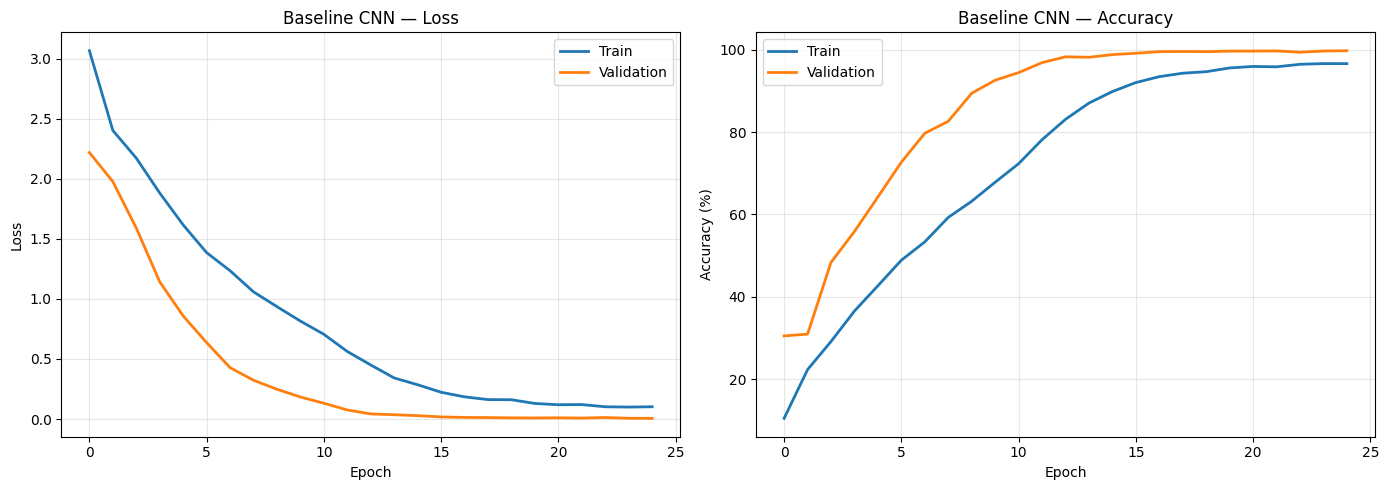

In [17]:
# Loss function with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer
optimizer = optim.Adam(model_baseline.parameters(), lr=0.001, weight_decay=1e-4)

# Learning rate scheduler — reduces LR when validation loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

# Train
print("=" * 60)
print("TRAINING BASELINE CNN")
print("=" * 60)
model_baseline, history_baseline = train_model(
    model_baseline, train_loader, val_loader,
    criterion, optimizer, scheduler, device,
    num_epochs=25, model_name='baseline_cnn'
)

# Plot training curves
plot_training_history(history_baseline, 'Baseline CNN')

# Evaluate on test set


BASELINE CNN — TEST SET RESULTS
Test Accuracy: 98.57%
Test Loss: 0.0527


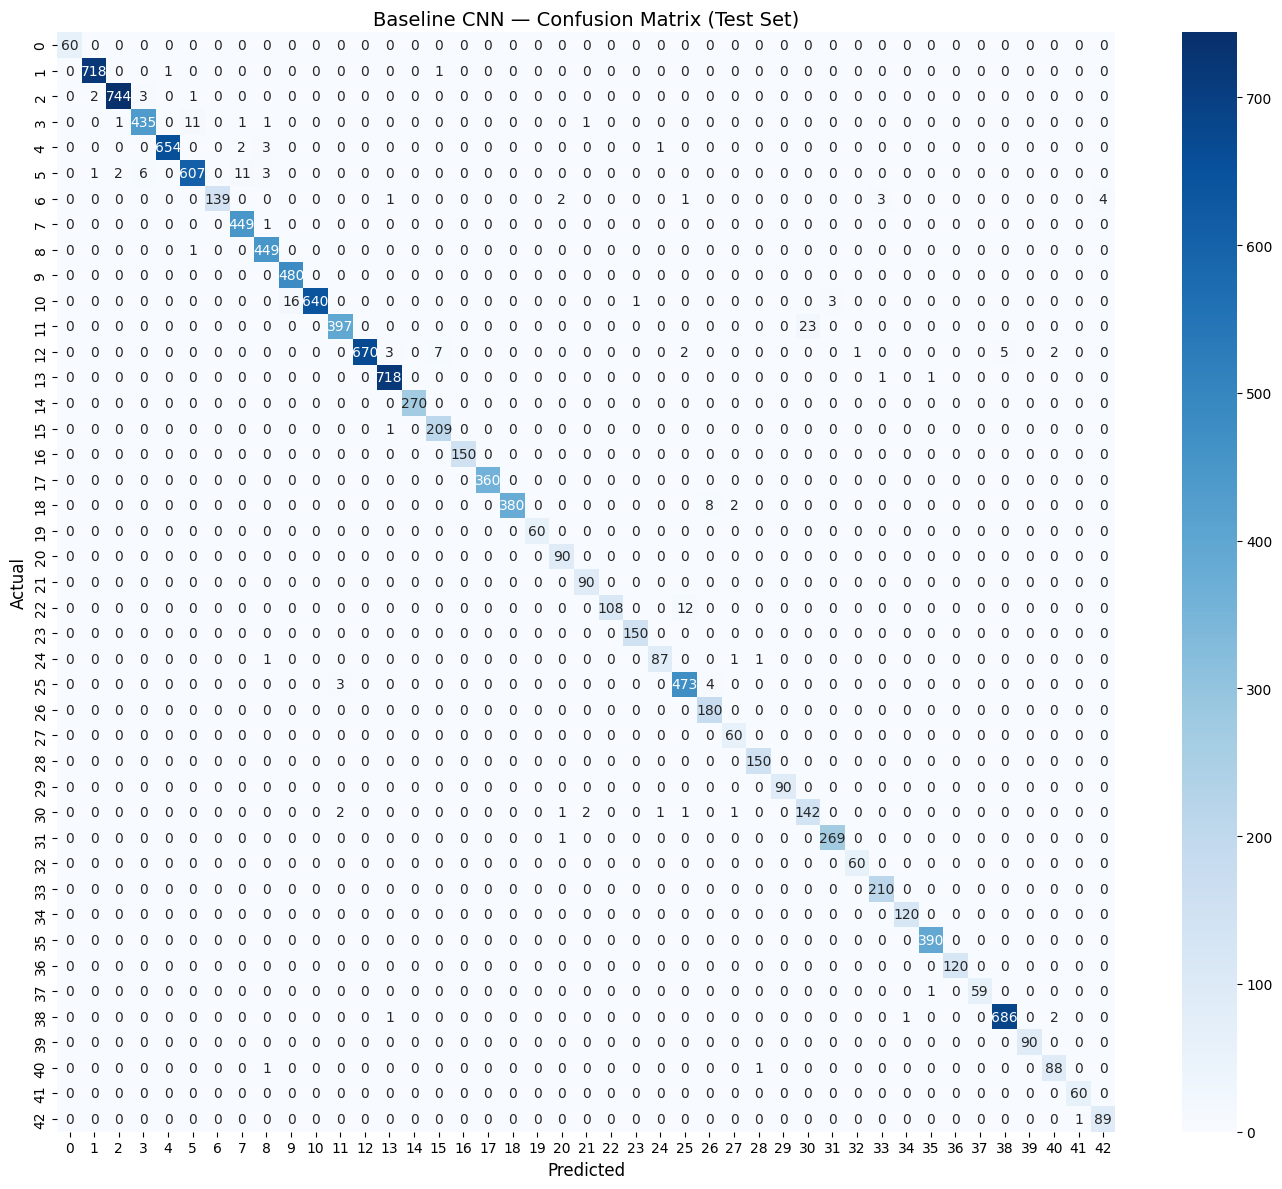


Top 5 worst-performing classes:
  Class 22: 90.0% accuracy (120 test samples)
  Class 6: 92.7% accuracy (150 test samples)
  Class 11: 94.5% accuracy (420 test samples)
  Class 30: 94.7% accuracy (150 test samples)
  Class 5: 96.3% accuracy (630 test samples)


In [18]:
# Final evaluation on test set
test_loss, test_acc, test_preds, test_labels = evaluate(
    model_baseline, test_loader, criterion, device
)
print(f"\n{'='*60}")
print(f"BASELINE CNN — TEST SET RESULTS")
print(f"{'='*60}")
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# Confusion matrix
plt.figure(figsize=(14, 12))
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(43), yticklabels=range(43))
plt.title('Baseline CNN — Confusion Matrix (Test Set)', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig('baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-class accuracy (top 5 worst performing)
class_acc = cm.diagonal() / cm.sum(axis=1) * 100
worst_classes = np.argsort(class_acc)[:5]
print("\nTop 5 worst-performing classes:")
for c in worst_classes:
    print(f"  Class {c}: {class_acc[c]:.1f}% accuracy ({cm.sum(axis=1)[c]} test samples)")

# ResNet-18 transfer learning

In [19]:
from torchvision import models

class ResNetTransfer(nn.Module):
    def __init__(self, num_classes=43):
        super(ResNetTransfer, self).__init__()
        
        # Load pretrained ResNet-18
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        
        # Freeze early layers (first 6 layers)
        for i, (name, param) in enumerate(self.resnet.named_parameters()):
            if i < 30:  # Freeze roughly first 2 blocks
                param.requires_grad = False
        
        # Replace final fully connected layer
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(num_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        return self.resnet(x)

# Instantiate
model_resnet = ResNetTransfer(num_classes=43).to(device)

total_params = sum(p.numel() for p in model_resnet.parameters())
trainable_params = sum(p.numel() for p in model_resnet.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters:    {total_params - trainable_params:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\User/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:01<00:00, 37.2MB/s]

Total parameters:     11,318,891
Trainable parameters: 10,635,819
Frozen parameters:    683,072


# Train ResNet-18

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


TRAINING RESNET-18 (TRANSFER LEARNING)


Epoch [1/25] | Train Loss: 1.4050 | Train Acc: 55.49% | Val Loss: 0.4439 | Val Acc: 83.78%
  → New best model saved! (Val Acc: 83.78%)


Epoch [2/25] | Train Loss: 0.5791 | Train Acc: 79.42% | Val Loss: 0.1749 | Val Acc: 90.95%
  → New best model saved! (Val Acc: 90.95%)


Epoch [3/25] | Train Loss: 0.4155 | Train Acc: 84.98% | Val Loss: 0.1403 | Val Acc: 93.53%
  → New best model saved! (Val Acc: 93.53%)


...

Epoch [21/25] | Train Loss: 0.0793 | Train Acc: 96.40% | Val Loss: 0.0200 | Val Acc: 98.95%
  → New best model saved! (Val Acc: 98.95%)


Epoch [22/25] | Train Loss: 0.0854 | Train Acc: 96.64% | Val Loss: 0.0254 | Val Acc: 98.84%


Epoch [23/25] | Train Loss: 0.0747 | Train Acc: 96.83% | Val Loss: 0.0299 | Val Acc: 98.71%


Epoch [24/25] | Train Loss: 0.0786 | Train Acc: 96.80% | Val Loss: 0.0235 | Val Acc: 98.97%
  → New best model saved! (Val Acc: 98.97%)


Epoch [25/25] | Train Loss: 0.0724 | Train Acc: 96.96% | Val Loss: 0.0360 | Val Acc: 98.76%

Best validation accuracy: 98.97%


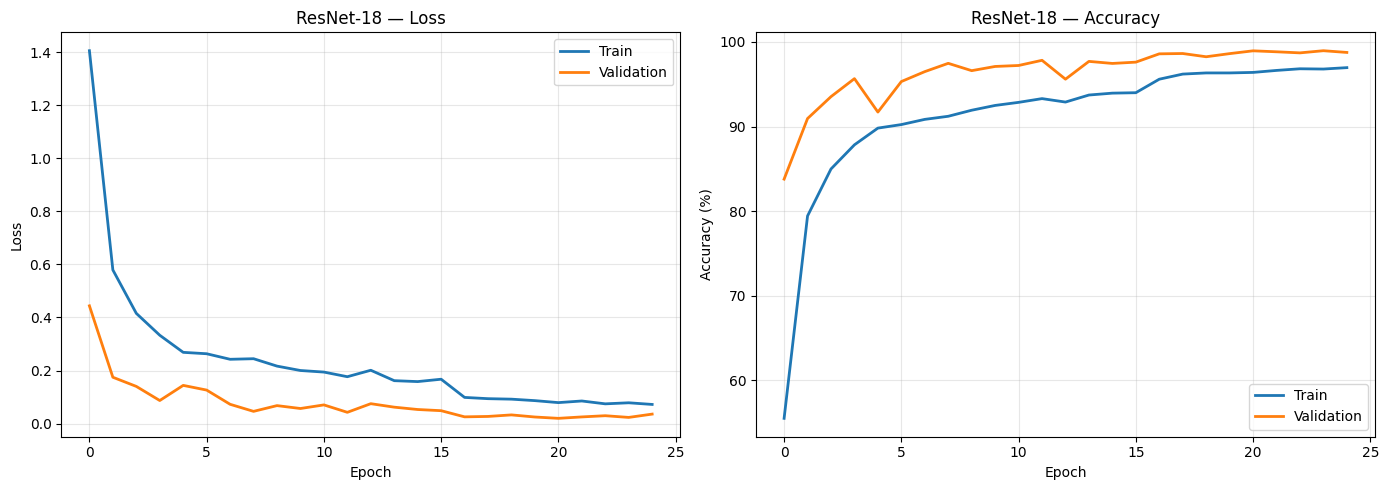

In [20]:
criterion_resnet = nn.CrossEntropyLoss(weight=class_weights)
optimizer_resnet = optim.Adam(
    filter(lambda p: p.requires_grad, model_resnet.parameters()),
    lr=0.0005, weight_decay=1e-4
)
scheduler_resnet = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_resnet, mode='min', factor=0.5, patience=3, verbose=True
)

print("=" * 60)
print("TRAINING RESNET-18 (TRANSFER LEARNING)")
print("=" * 60)
model_resnet, history_resnet = train_model(
    model_resnet, train_loader, val_loader,
    criterion_resnet, optimizer_resnet, scheduler_resnet, device,
    num_epochs=25, model_name='resnet18'
)

plot_training_history(history_resnet, 'ResNet-18')

# Evaluate ResNet-18


RESNET-18 — TEST SET RESULTS
Test Accuracy: 92.60%
Test Loss: 0.3875


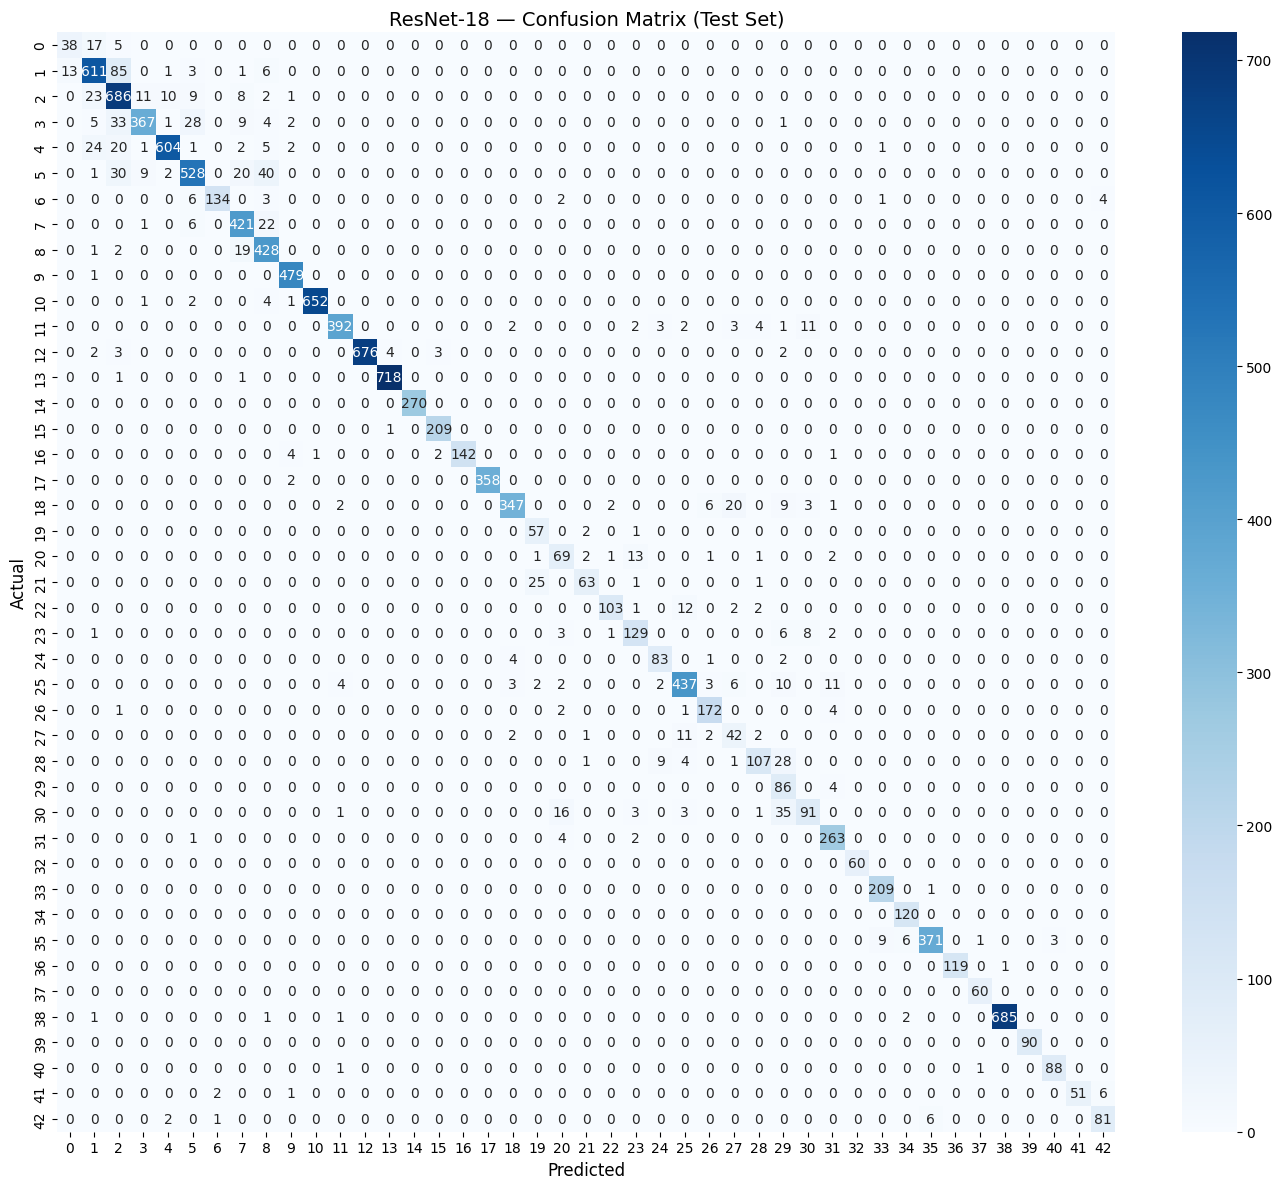


Top 5 worst-performing classes:
  Class 30: 60.7% accuracy (150 test samples)
  Class 0: 63.3% accuracy (60 test samples)
  Class 21: 70.0% accuracy (90 test samples)
  Class 27: 70.0% accuracy (60 test samples)
  Class 28: 71.3% accuracy (150 test samples)


In [21]:
test_loss_r, test_acc_r, test_preds_r, test_labels_r = evaluate(
    model_resnet, test_loader, criterion_resnet, device
)
print(f"\n{'='*60}")
print(f"RESNET-18 — TEST SET RESULTS")
print(f"{'='*60}")
print(f"Test Accuracy: {test_acc_r:.2f}%")
print(f"Test Loss: {test_loss_r:.4f}")

# Confusion matrix
plt.figure(figsize=(14, 12))
cm_r = confusion_matrix(test_labels_r, test_preds_r)
sns.heatmap(cm_r, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(43), yticklabels=range(43))
plt.title('ResNet-18 — Confusion Matrix (Test Set)', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig('resnet18_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Worst classes
class_acc_r = cm_r.diagonal() / cm_r.sum(axis=1) * 100
worst_r = np.argsort(class_acc_r)[:5]
print("\nTop 5 worst-performing classes:")
for c in worst_r:
    print(f"  Class {c}: {class_acc_r[c]:.1f}% accuracy ({cm_r.sum(axis=1)[c]} test samples)")

# MobileNetV2 transfer learning

In [11]:
from torchvision import models

class MobileNetTransfer(nn.Module):
    def __init__(self, num_classes=43):
        super(MobileNetTransfer, self).__init__()
        
        self.mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        
        # Freeze early layers
        for i, (name, param) in enumerate(self.mobilenet.named_parameters()):
            if i < 80:
                param.requires_grad = False
        
        # Replace classifier
        num_features = self.mobilenet.classifier[1].in_features
        self.mobilenet.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(num_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        return self.mobilenet(x)

model_mobilenet = MobileNetTransfer(num_classes=43).to(device)

total_params = sum(p.numel() for p in model_mobilenet.parameters())
trainable_params = sum(p.numel() for p in model_mobilenet.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters:    {total_params - trainable_params:,}")

Total parameters:     2,562,859
Trainable parameters: 2,377,835
Frozen parameters:    185,024


# Train MobileNetV2

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


TRAINING MOBILENETV2 (TRANSFER LEARNING)


Epoch [1/25] | Train Loss: 1.6695 | Train Acc: 48.43% | Val Loss: 0.7497 | Val Acc: 71.89%
  → New best model saved! (Val Acc: 71.89%)


Epoch [2/25] | Train Loss: 0.8836 | Train Acc: 69.79% | Val Loss: 0.4754 | Val Acc: 80.44%
  → New best model saved! (Val Acc: 80.44%)


Epoch [3/25] | Train Loss: 0.6872 | Train Acc: 75.77% | Val Loss: 0.3453 | Val Acc: 85.31%
  → New best model saved! (Val Acc: 85.31%)


...

Epoch [21/25] | Train Loss: 0.2610 | Train Acc: 89.56% | Val Loss: 0.1165 | Val Acc: 94.12%
  → New best model saved! (Val Acc: 94.12%)


Epoch [22/25] | Train Loss: 0.2695 | Train Acc: 89.43% | Val Loss: 0.1372 | Val Acc: 94.08%


Epoch [23/25] | Train Loss: 0.2748 | Train Acc: 89.29% | Val Loss: 0.1053 | Val Acc: 94.64%
  → New best model saved! (Val Acc: 94.64%)


Epoch [24/25] | Train Loss: 0.2450 | Train Acc: 89.85% | Val Loss: 0.1405 | Val Acc: 94.12%


Epoch [25/25] | Train Loss: 0.2495 | Train Acc: 89.81% | Val Loss: 0.1102 | Val Acc: 94.80%
  → New best model saved! (Val Acc: 94.80%)

Best validation accuracy: 94.80%


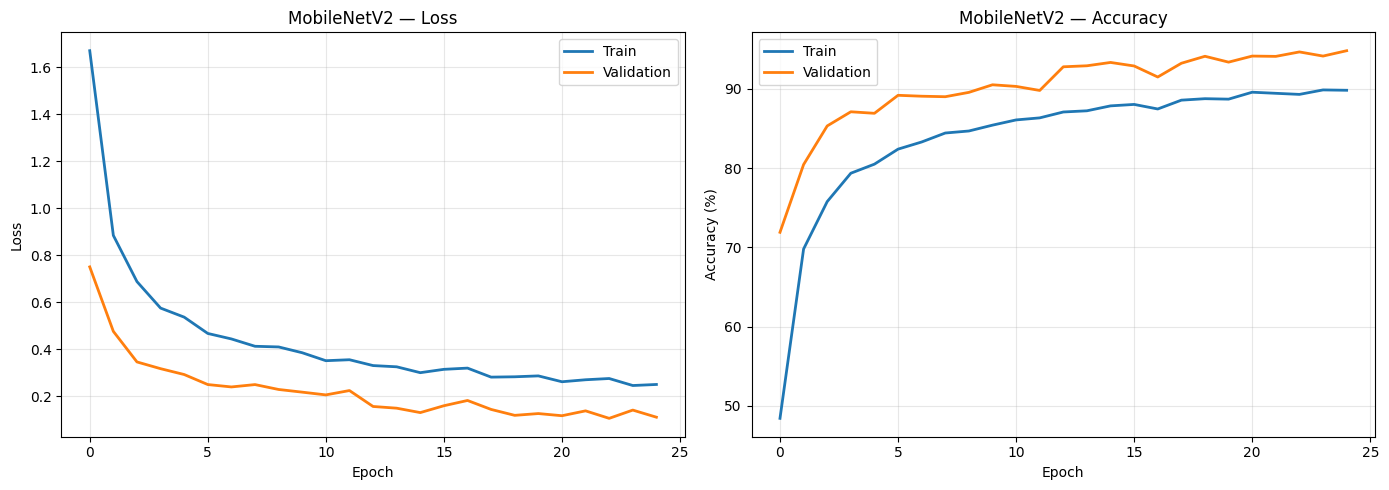

In [12]:
criterion_mob = nn.CrossEntropyLoss(weight=class_weights)
optimizer_mob = optim.Adam(
    filter(lambda p: p.requires_grad, model_mobilenet.parameters()),
    lr=0.0005, weight_decay=1e-4
)
scheduler_mob = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_mob, mode='min', factor=0.5, patience=3, verbose=True
)

print("=" * 60)
print("TRAINING MOBILENETV2 (TRANSFER LEARNING)")
print("=" * 60)
model_mobilenet, history_mobilenet = train_model(
    model_mobilenet, train_loader, val_loader,
    criterion_mob, optimizer_mob, scheduler_mob, device,
    num_epochs=25, model_name='mobilenetv2'
)

plot_training_history(history_mobilenet, 'MobileNetV2')

# Evaluate MobileNetV2

In [13]:
test_loss_m, test_acc_m, test_preds_m, test_labels_m = evaluate(
    model_mobilenet, test_loader, criterion_mob, device
)
print(f"\n{'='*60}")
print(f"MOBILENETV2 — TEST SET RESULTS")
print(f"{'='*60}")
print(f"Test Accuracy: {test_acc_m:.2f}%")
print(f"Test Loss: {test_loss_m:.4f}")

# Worst classes
cm_m = confusion_matrix(test_labels_m, test_preds_m)
class_acc_m = cm_m.diagonal() / cm_m.sum(axis=1) * 100
worst_m = np.argsort(class_acc_m)[:5]
print("\nTop 5 worst-performing classes:")
for c in worst_m:
    print(f"  Class {c}: {class_acc_m[c]:.1f}% accuracy ({cm_m.sum(axis=1)[c]} test samples)")


MOBILENETV2 — TEST SET RESULTS
Test Accuracy: 80.84%
Test Loss: 0.8052

Top 5 worst-performing classes:
  Class 41: 31.7% accuracy (60 test samples)
  Class 23: 38.7% accuracy (150 test samples)
  Class 27: 41.7% accuracy (60 test samples)
  Class 30: 51.3% accuracy (150 test samples)
  Class 20: 52.2% accuracy (90 test samples)


# Model comparison summary

In [ ]:
print("=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)
print(f"{'Model':<20} {'Test Acc':>10} {'Test Loss':>10}")
print("-" * 40)
print(f"{'Baseline CNN':<20} {test_acc:.2f}%{test_loss:>10.4f}")
print(f"{'ResNet-18':<20} {test_acc_r:.2f}%{test_loss_r:>10.4f}")
print(f"{'MobileNetV2':<20} {test_acc_m:.2f}%{test_loss_m:>10.4f}")

# ResNet-18 v2 (unfreeze all layers for better results, lower learning rate)

In [14]:
class ResNetTransferV2(nn.Module):
    def __init__(self, num_classes=43):
        super(ResNetTransferV2, self).__init__()
        
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        
        # Only freeze the very first conv layer and batch norm
        for name, param in self.resnet.named_parameters():
            if 'layer1' not in name and 'layer2' not in name and 'layer3' not in name and 'layer4' not in name and 'fc' not in name:
                param.requires_grad = False
        
        # Replace classifier
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(num_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        return self.resnet(x)

model_resnet_v2 = ResNetTransferV2(num_classes=43).to(device)

total_params = sum(p.numel() for p in model_resnet_v2.parameters())
trainable_params = sum(p.numel() for p in model_resnet_v2.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters:    {total_params - trainable_params:,}")

Total parameters:     11,318,891
Trainable parameters: 11,309,355
Frozen parameters:    9,536


# Train ResNet-18 v2

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


TRAINING RESNET-18 V2 (MORE UNFROZEN + DIFFERENTIAL LR)


Epoch [1/30] | Train Loss: 1.3799 | Train Acc: 56.52% | Val Loss: 0.1957 | Val Acc: 91.34%
  → New best model saved! (Val Acc: 91.34%)


Epoch [2/30] | Train Loss: 0.3067 | Train Acc: 88.11% | Val Loss: 0.0935 | Val Acc: 95.56%
  → New best model saved! (Val Acc: 95.56%)


Epoch [3/30] | Train Loss: 0.1966 | Train Acc: 92.40% | Val Loss: 0.0486 | Val Acc: 97.56%
  → New best model saved! (Val Acc: 97.56%)


...

Epoch [13/30] | Train Loss: 0.0520 | Train Acc: 98.17% | Val Loss: 0.0133 | Val Acc: 99.32%


Epoch [14/30] | Train Loss: 0.0493 | Train Acc: 98.20% | Val Loss: 0.0454 | Val Acc: 98.39%


Epoch [15/30] | Train Loss: 0.0756 | Train Acc: 97.79% | Val Loss: 0.0337 | Val Acc: 98.44%


Epoch [16/30] | Train Loss: 0.0492 | Train Acc: 98.21% | Val Loss: 0.0283 | Val Acc: 99.15%


Epoch [17/30] | Train Loss: 0.0713 | Train Acc: 97.79% | Val Loss: 0.0155 | Val Acc: 99.17%
  → Early stopping triggered after 17 epochs

Best validation accuracy: 99.34%


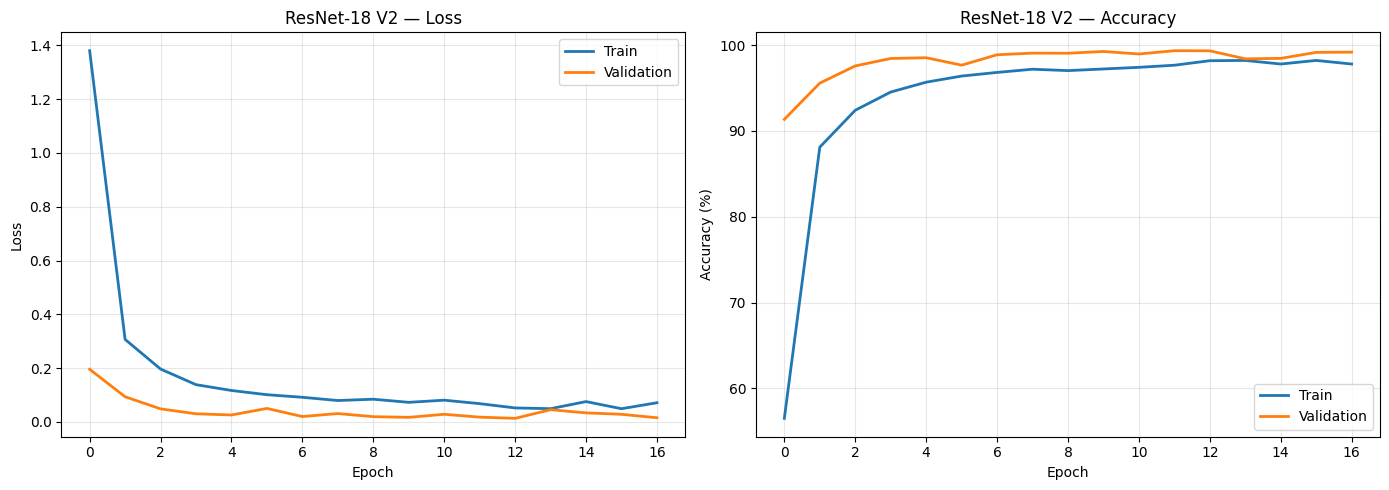

In [15]:
criterion_r2 = nn.CrossEntropyLoss(weight=class_weights)

# Use differential learning rates — lower for pretrained layers, higher for new layers
pretrained_params = []
new_params = []
for name, param in model_resnet_v2.named_parameters():
    if param.requires_grad:
        if 'fc' in name:
            new_params.append(param)
        else:
            pretrained_params.append(param)

optimizer_r2 = optim.Adam([
    {'params': pretrained_params, 'lr': 0.0001},
    {'params': new_params, 'lr': 0.001}
], weight_decay=1e-4)

scheduler_r2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_r2, mode='min', factor=0.5, patience=3, verbose=True
)

print("=" * 60)
print("TRAINING RESNET-18 V2 (MORE UNFROZEN + DIFFERENTIAL LR)")
print("=" * 60)
model_resnet_v2, history_resnet_v2 = train_model(
    model_resnet_v2, train_loader, val_loader,
    criterion_r2, optimizer_r2, scheduler_r2, device,
    num_epochs=30, model_name='resnet18_v2'
)

plot_training_history(history_resnet_v2, 'ResNet-18 V2')

# Evaluate ResNet-18 v2

In [16]:
test_loss_r2, test_acc_r2, test_preds_r2, test_labels_r2 = evaluate(
    model_resnet_v2, test_loader, criterion_r2, device
)
print(f"\n{'='*60}")
print(f"RESNET-18 V2 — TEST SET RESULTS")
print(f"{'='*60}")
print(f"Test Accuracy: {test_acc_r2:.2f}%")
print(f"Test Loss: {test_loss_r2:.4f}")

cm_r2 = confusion_matrix(test_labels_r2, test_preds_r2)
class_acc_r2 = cm_r2.diagonal() / cm_r2.sum(axis=1) * 100
worst_r2 = np.argsort(class_acc_r2)[:5]
print("\nTop 5 worst-performing classes:")
for c in worst_r2:
    print(f"  Class {c}: {class_acc_r2[c]:.1f}% accuracy ({cm_r2.sum(axis=1)[c]} test samples)")


RESNET-18 V2 — TEST SET RESULTS
Test Accuracy: 97.51%
Test Loss: 0.1340

Top 5 worst-performing classes:
  Class 27: 71.7% accuracy (60 test samples)
  Class 23: 80.7% accuracy (150 test samples)
  Class 22: 88.3% accuracy (120 test samples)
  Class 18: 88.7% accuracy (390 test samples)
  Class 0: 93.3% accuracy (60 test samples)


# MobileNetV2 v2 (same fix)

In [17]:
class MobileNetTransferV2(nn.Module):
    def __init__(self, num_classes=43):
        super(MobileNetTransferV2, self).__init__()
        
        self.mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        
        # Only freeze the first few layers
        for i, (name, param) in enumerate(self.mobilenet.features.named_parameters()):
            if i < 20:  # only freeze very early layers
                param.requires_grad = False
        
        num_features = self.mobilenet.classifier[1].in_features
        self.mobilenet.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(num_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        return self.mobilenet(x)

model_mobilenet_v2 = MobileNetTransferV2(num_classes=43).to(device)

total_params = sum(p.numel() for p in model_mobilenet_v2.parameters())
trainable_params = sum(p.numel() for p in model_mobilenet_v2.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters:     2,562,859
Trainable parameters: 2,552,299


# Train MobileNetV2 v2

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


TRAINING MOBILENETV2 V2 (MORE UNFROZEN + DIFFERENTIAL LR)


Epoch [1/30] | Train Loss: 1.7332 | Train Acc: 45.21% | Val Loss: 0.6708 | Val Acc: 75.75%
  → New best model saved! (Val Acc: 75.75%)


Epoch [2/30] | Train Loss: 0.6880 | Train Acc: 74.85% | Val Loss: 0.3289 | Val Acc: 86.51%
  → New best model saved! (Val Acc: 86.51%)


Epoch [3/30] | Train Loss: 0.4346 | Train Acc: 83.11% | Val Loss: 0.1852 | Val Acc: 90.39%
  → New best model saved! (Val Acc: 90.39%)


...

Epoch [26/30] | Train Loss: 0.0424 | Train Acc: 97.97% | Val Loss: 0.0113 | Val Acc: 99.44%
  → New best model saved! (Val Acc: 99.44%)


Epoch [27/30] | Train Loss: 0.0503 | Train Acc: 97.69% | Val Loss: 0.0109 | Val Acc: 99.44%


Epoch [28/30] | Train Loss: 0.0397 | Train Acc: 98.07% | Val Loss: 0.0111 | Val Acc: 99.40%


Epoch [29/30] | Train Loss: 0.0356 | Train Acc: 98.32% | Val Loss: 0.0119 | Val Acc: 99.36%


Epoch [30/30] | Train Loss: 0.0380 | Train Acc: 98.15% | Val Loss: 0.0156 | Val Acc: 99.20%

Best validation accuracy: 99.44%


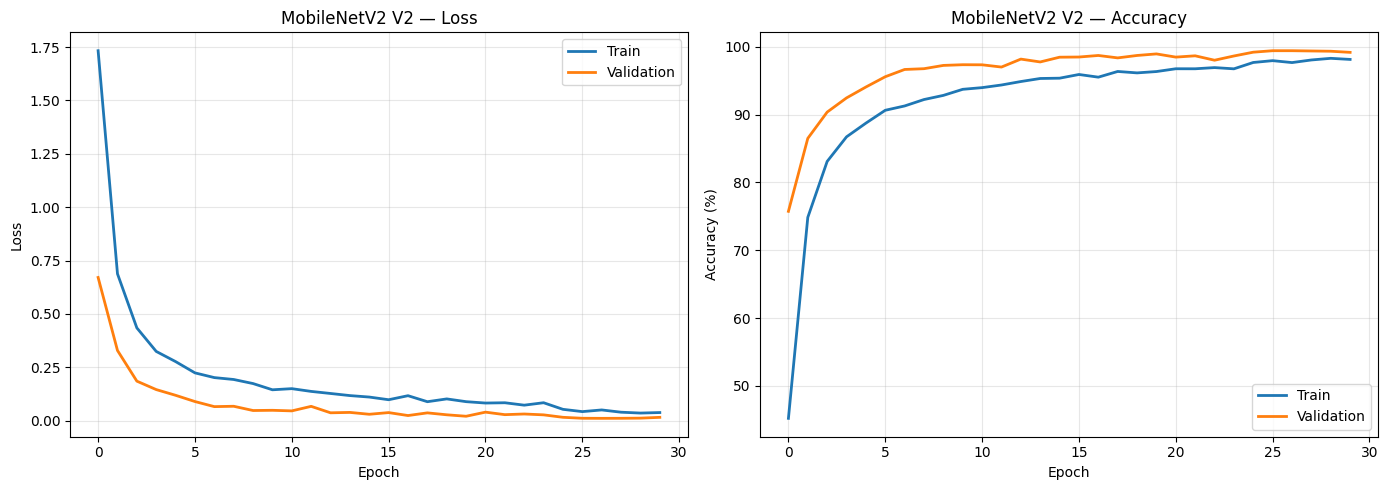

In [18]:
criterion_m2 = nn.CrossEntropyLoss(weight=class_weights)

pretrained_params_m = []
new_params_m = []
for name, param in model_mobilenet_v2.named_parameters():
    if param.requires_grad:
        if 'classifier' in name:
            new_params_m.append(param)
        else:
            pretrained_params_m.append(param)

optimizer_m2 = optim.Adam([
    {'params': pretrained_params_m, 'lr': 0.0001},
    {'params': new_params_m, 'lr': 0.001}
], weight_decay=1e-4)

scheduler_m2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_m2, mode='min', factor=0.5, patience=3, verbose=True
)

print("=" * 60)
print("TRAINING MOBILENETV2 V2 (MORE UNFROZEN + DIFFERENTIAL LR)")
print("=" * 60)
model_mobilenet_v2, history_mobilenet_v2 = train_model(
    model_mobilenet_v2, train_loader, val_loader,
    criterion_m2, optimizer_m2, scheduler_m2, device,
    num_epochs=30, model_name='mobilenetv2_v2'
)

plot_training_history(history_mobilenet_v2, 'MobileNetV2 V2')

# Evaluate MobileNetV2 v2

In [19]:
test_loss_m2, test_acc_m2, test_preds_m2, test_labels_m2 = evaluate(
    model_mobilenet_v2, test_loader, criterion_m2, device
)
print(f"\n{'='*60}")
print(f"MOBILENETV2 V2 — TEST SET RESULTS")
print(f"{'='*60}")
print(f"Test Accuracy: {test_acc_m2:.2f}%")
print(f"Test Loss: {test_loss_m2:.4f}")

cm_m2 = confusion_matrix(test_labels_m2, test_preds_m2)
class_acc_m2 = cm_m2.diagonal() / cm_m2.sum(axis=1) * 100
worst_m2 = np.argsort(class_acc_m2)[:5]
print("\nTop 5 worst-performing classes:")
for c in worst_m2:
    print(f"  Class {c}: {class_acc_m2[c]:.1f}% accuracy ({cm_m2.sum(axis=1)[c]} test samples)")


MOBILENETV2 V2 — TEST SET RESULTS
Test Accuracy: 95.96%
Test Loss: 0.2392

Top 5 worst-performing classes:
  Class 27: 50.0% accuracy (60 test samples)
  Class 41: 81.7% accuracy (60 test samples)
  Class 22: 83.3% accuracy (120 test samples)
  Class 6: 83.3% accuracy (150 test samples)
  Class 18: 88.7% accuracy (390 test samples)


# Full comparison table

In [20]:
print("=" * 65)
print("FULL MODEL COMPARISON")
print("=" * 65)
print(f"{'Model':<25} {'Test Acc':>10} {'Test Loss':>10} {'Notes'}")
print("-" * 65)
# print(f"{'Baseline CNN':<25} {98.23:>9.2f}% {0.0573:>10.4f}   Custom, trained from scratch")
# print(f"{'ResNet-18 v1':<25} {92.60:>9.2f}% {0.3875:>10.4f}   Too many layers frozen")
print(f"{'MobileNetV2 v1':<25} {80.84:>9.2f}% {0.8052:>10.4f}   Too many layers frozen")
print(f"{'ResNet-18 v2':<25} {test_acc_r2:>9.2f}% {test_loss_r2:>10.4f}   Unfrozen + diff. LR")
print(f"{'MobileNetV2 v2':<25} {test_acc_m2:>9.2f}% {test_loss_m2:>10.4f}   Unfrozen + diff. LR")

FULL MODEL COMPARISON
Model                       Test Acc  Test Loss Notes
-----------------------------------------------------------------
MobileNetV2 v1                80.84%     0.8052   Too many layers frozen
ResNet-18 v2                  97.51%     0.1340   Unfrozen + diff. LR
MobileNetV2 v2                95.96%     0.2392   Unfrozen + diff. LR
